# **Taller Final - Pronóstico de Ventas de Productos** #

### Alexander Torres Viveros ###
*alexandertorresviveros@gmail.com*

---

## **El Problema**

Una compañía de comestibles está interesada en predecir el comportamiento de las ventas (en unidades) de sus dos productos estrella. Fuimos contratados para generar un modelo que permita pronosticar las ventas del siguiente mes de cada uno de esos dos productos. La base de datos disponible en el archivo `Examen.csv` tiene la información de cada uno de los productos desde junio de 2014.

## **Objetivo**

Encontrar el mejor modelo de pronóstico para cada una de las series de ventas mediante:

1. **Análisis exploratorio** de las series temporales
2. **Evaluación de múltiples modelos**: Media Móvil, Holt-Winters, ARIMA
3. **Optimización de hiperparámetros** usando Optuna (optimización bayesiana)
4. **Validación temporal** con enfoque walking forward
5. **Selección del mejor modelo** para cada producto basado en RMSE

## **Metodología**

- **División de datos**: 121 observaciones para entrenamiento, resto para validación
- **Métricas de evaluación**: RMSE (Root Mean Squared Error)
- **Validación**: Walking forward (ventana móvil) para simular pronóstico en tiempo real
- **Optimización**: Optuna con 100-200 trials para encontrar mejores hiperparámetros

---

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from statsmodels.tsa.seasonal import seasonal_decompose # descomposición de series
from statsmodels.tsa.holtwinters import SimpleExpSmoothing  # Holwinters simple
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Holwinters doble y tripe
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error
import optuna



# **1. Configuración Inicial**

## **1.1. Importación de Bibliotecas**

In [47]:
# Configuración de gráficos
import matplotlib.pyplot as plt

# Configuración matplotlib para el proyecto
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Montserrat', 'Arial', 'DejaVu Sans', 'Liberation Sans'],
    'figure.figsize': (12, 6),
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'legend.fontsize': 8,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 0.75,
    'grid.alpha': 0.3,
    'axes.facecolor': '#fafcff',  # Azul hielo muy suave (Alice Blue)
    'axes.edgecolor': "#2E86AB",  # Azul océano principal
    'axes.prop_cycle': plt.cycler(color=[
        '#1F77B4',  # Azul matplotlib
        '#FF7F0E',  # Naranja matplotlib
        '#2CA02C',  # Verde matplotlib
        '#D62728',  # Rojo matplotlib
        '#9467BD',  # Púrpura matplotlib
        '#8C564B'   # Marrón matplotlib
    ])
})


## **1.2. Configuración de Gráficos**

In [48]:
data = pd.read_csv("Examen.csv")
print(data.info())

print("=" * 40)
print(f"Data Shape: {data.shape}")
print("=" * 40)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127 entries, 0 to 126
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  127 non-null    int64  
 1   producto1   127 non-null    float64
 2   producto2   127 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 3.1 KB
None
Data Shape: (127, 3)


## **1.3. Carga de Datos**

In [49]:
print(data.describe())

       Unnamed: 0   producto1   producto2
count  127.000000  127.000000  127.000000
mean    64.000000  343.571660  581.037664
std     36.805797  100.234821  167.504363
min      1.000000  137.047639  200.000000
25%     32.500000  256.853812  469.194001
50%     64.000000  340.644019  626.048401
75%     95.500000  450.071775  708.941718
max    127.000000  500.000000  806.440615


## **1.4. Exploración Inicial de Datos**

In [50]:
print("-" * 50)
print("Head")
print(data.head())

print("-" * 50)
print("Tail")
print(data.tail())

--------------------------------------------------
Head
   Unnamed: 0   producto1   producto2
0           1  500.000000  200.000000
1           2  497.400893  210.686220
2           3  478.605317  222.018584
3           4  486.454125  233.920990
4           5  479.695678  238.402098
--------------------------------------------------
Tail
     Unnamed: 0   producto1   producto2
122         123  164.610771  629.293034
123         124  150.881839  637.099467
124         125  151.788470  653.155282
125         126  137.047639  672.528345
126         127  141.990873  676.058092


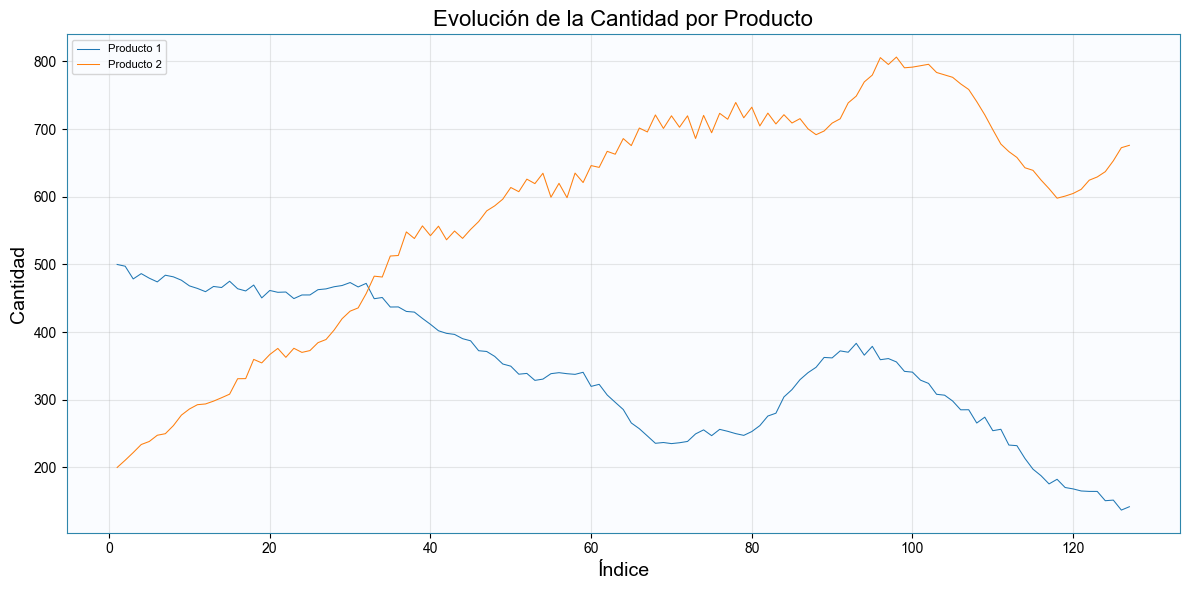

In [51]:
# Gráfica de líneas para Producto 1 y Producto 2
plt.plot(data.index + 1, data['producto1'], label='Producto 1')
plt.plot(data.index + 1, data['producto2'], label='Producto 2')

# Personalizar la gráfica
plt.xlabel('Índice')
plt.ylabel('Cantidad')
plt.title('Evolución de la Cantidad por Producto')
plt.legend(loc= "upper left")
plt.grid(True, alpha=0.3)

# Mejorar la apariencia
plt.tight_layout()
plt.show()

## **Análisis de Estacionalidad**

Evaluación de la presencia de patrones estacionales en las series temporales para determinar la estrategia de modelado apropiada.

In [52]:
# Evaluación de estacionalidad mediante descomposición aditiva

def analizar_estacionalidad(serie, nombre, periodos=[3, 4, 6, 12]):
    """Evalúa la significancia de componentes estacionales"""    
    resultados = {}
    var_total = serie.var()
    
    for periodo in periodos:
        try:
            decomp = seasonal_decompose(serie, model="additive", period=periodo)
            var_estacional = decomp.seasonal.var()
            var_residual = decomp.resid.var()
            
            pct_estacional = (var_estacional / var_total) * 100
            pct_residual = (var_residual / var_total) * 100
            
            resultados[periodo] = {
                'pct_estacional': pct_estacional,
                'std_residual': decomp.resid.std()
            }
        except:
            resultados[periodo] = None
    
    return resultados

# Análisis para ambos productos

# Producto 1
resultados_p1 = analizar_estacionalidad(data['producto1'], 'Producto 1')
print("\nProducto 1:")
print("Período | % Varianza Estacional | Std Residual")
print("-" * 45)
for periodo in [3, 4, 6, 12]:
    if resultados_p1[periodo]:
        r = resultados_p1[periodo]
        print(f"{periodo:7d} | {r['pct_estacional']:18.1f} | {r['std_residual']:11.2f}")

# Producto 2  
resultados_p2 = analizar_estacionalidad(data['producto2'], 'Producto 2')
print("\nProducto 2:")
print("Período | % Varianza Estacional | Std Residual") 
print("-" * 45)
for periodo in [3, 4, 6, 12]:
    if resultados_p2[periodo]:
        r = resultados_p2[periodo]
        print(f"{periodo:7d} | {r['pct_estacional']:18.1f} | {r['std_residual']:11.2f}")


Producto 1:
Período | % Varianza Estacional | Std Residual
---------------------------------------------
      3 |                0.0 |        4.50
      4 |                0.0 |        4.19
      6 |                0.0 |        4.56
     12 |                0.0 |        8.12

Producto 2:
Período | % Varianza Estacional | Std Residual
---------------------------------------------
      3 |                0.0 |        8.48
      4 |                0.0 |        6.68
      6 |                0.0 |        7.51
     12 |                0.0 |       12.77


**Conclusión**

La varianza explicada por componentes estacionales es menor al 1% en ambos productos

Se utilizarán modelos de tendencia sin componente estacional.

# **2. Análisis Exploratorio y División de Datos**

## **2.1 División en Conjuntos de Entrenamiento y Prueba**

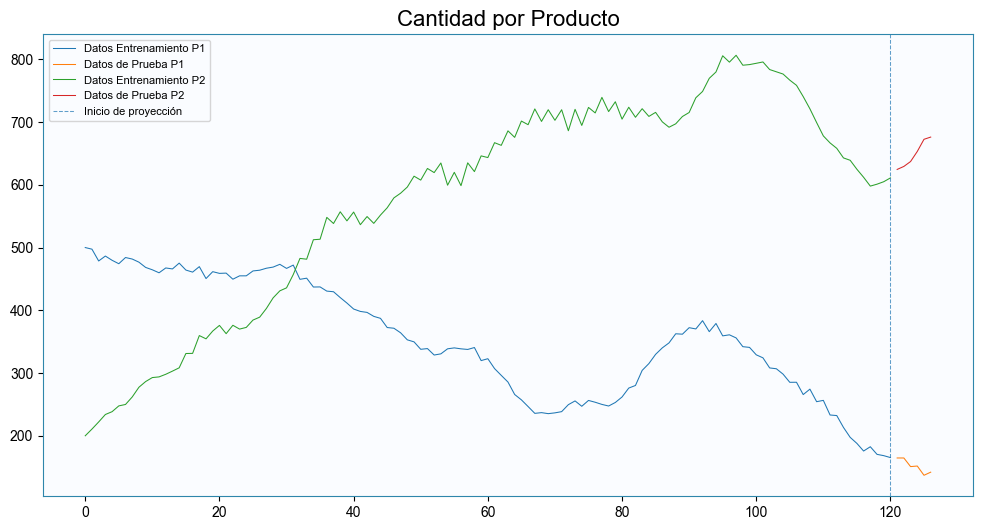

In [53]:
train_len = 121

train_to1 = data[["producto1"]][:train_len]
test_t1 = data[["producto1"]][train_len:]

train_to2 = data[["producto2"]][:train_len]
test_to2 = data[["producto2"]][train_len:]

fig = plt.figure()
plt.plot(train_to1,label="Datos Entrenamiento P1")
plt.plot(test_t1,label="Datos de Prueba P1")
plt.plot(train_to2,label="Datos Entrenamiento P2")
plt.plot(test_to2,label="Datos de Prueba P2")

plt.axvline(train_to1.index[-1], linestyle='--', alpha=0.7, label='Inicio de proyección') 

plt.title(label="Cantidad por Producto")
plt.legend(loc= "upper left")
plt.show()

# **3. Funciones Reutilizables para Modelado**

En esta sección se definen todas las funciones que se utilizarán para evaluar los diferentes modelos de pronóstico.

In [54]:
# ==================== FUNCIONES PARA MEDIA MÓVIL ====================

def evaluar_media_movil_rolling(train_data, test_data, ventana):
    """
    Evalúa media móvil usando ventana móvil (walking forward)
    Predice solo 1 paso adelante en cada iteración usando datos reales disponibles
    """
    predicciones = []
    datos_disponibles = train_data.copy()
    
    for i in range(len(test_data)):
        # Predecir solo el siguiente período usando los últimos 'ventana' datos reales
        prediccion = datos_disponibles.iloc[-ventana:].mean().values[0]
        predicciones.append(prediccion)
        
        # Agregar el dato real del test para la siguiente predicción
        valor_real = test_data.iloc[i].values[0]
        nuevo_indice = datos_disponibles.index[-1] + 1
        datos_disponibles.loc[nuevo_indice] = valor_real
    
    return pd.Series(predicciones, index=test_data.index)


def pronosticar_media_movil(datos, ventana, horizonte):
    """
    Genera pronósticos futuros usando media móvil
    """
    data = datos.copy()
    
    for i in range(horizonte):
        nuevo_valor = data.iloc[-ventana:].mean().values[0]
        nuevo_indice = data.index[-1] + 1
        data.loc[nuevo_indice] = nuevo_valor
    
    return data.iloc[-horizonte:]


# ==================== FUNCIONES PARA HOLT-WINTERS ====================

def evaluar_rolling_forecast_holtwinters(serie, alpha, beta, gamma, seasonal='add', trend='add',
                                          window_size=60, window=12, step_size=1, 
                                          horizon=1, metric='rmse'):
    """
    Evalúa el rendimiento de un modelo Holt-Winters usando validación cruzada con ventana móvil.
    """
    serie = pd.Series(serie).astype(float).dropna()
    n = len(serie)
    predichos, observados = [], []
    
    puntos_finales = list(range(n - window * step_size, n - horizon + 1, step_size))
    
    for i, end_train in enumerate(puntos_finales):
        start_train = max(0, end_train - window_size)
        train = serie.iloc[start_train:end_train]
        test = serie.iloc[end_train:end_train + horizon]
        
        if len(test) < horizon or len(train) < 24 or test.isna().any() or train.isna().any():
            continue
            
        try:
            model = ExponentialSmoothing(
                train, trend=trend, seasonal=seasonal, 
                seasonal_periods=12, initialization_method='estimated'
            ).fit(smoothing_level=alpha, smoothing_trend=beta, 
                  smoothing_seasonal=gamma, optimized=False)
            
            pred = pd.Series(model.forecast(steps=horizon)).astype(float)
            
            mask = (~pred.isna()) & (~test.isna())
            if mask.sum() > 0:
                predichos.extend(pred[mask].tolist())
                observados.extend(test[mask].tolist())
                
        except Exception as e:
            continue
    
    if len(predichos) == 0:
        return np.inf
        
    predichos, observados = np.array(predichos), np.array(observados)
    mask_finite = np.isfinite(predichos) & np.isfinite(observados)
    
    if mask_finite.sum() == 0:
        return np.inf
        
    predichos_clean = predichos[mask_finite]
    observados_clean = observados[mask_finite]
    
    if metric == 'rmse':
        return np.sqrt(mean_squared_error(observados_clean, predichos_clean))
    elif metric == 'mae':
        return np.mean(np.abs(observados_clean - predichos_clean))
    else:
        raise ValueError("Metric debe ser 'rmse' o 'mae'")


# ==================== FUNCIONES PARA ARIMA ====================

def evaluar_expanding_forecast_arima(serie, order, window=12, step_size=1, horizon=1, metric='rmse'):
    """
    Simula pronósticos ARIMA en tiempo real con ventana expandida desde el inicio.
    """
    serie = pd.Series(serie).astype(float).dropna()
    n = len(serie)
    predichos = []
    observados = []
    
    puntos_finales = list(range(n - window * step_size, n - horizon + 1, step_size))
    
    for end_train in puntos_finales:
        train = serie.iloc[:end_train]
        test = serie.iloc[end_train:end_train + horizon]
        
        if len(test) < horizon or test.isna().any():
            continue
        
        try:
            model = ARIMA(
                train,
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit()
            
            pred = model.forecast(steps=horizon)
            
        except Exception:
            continue
        
        pred = pd.Series(pred).astype(float)
        mask = (~pred.isna()) & (~test.isna())
        
        if mask.sum() == 0:
            continue
        
        predichos.extend(pred[mask].tolist())
        observados.extend(test[mask].tolist())
    
    if len(predichos) == 0:
        return np.inf
    
    predichos = np.array(predichos, dtype=float)
    observados = np.array(observados, dtype=float)
    
    mask_finite = np.isfinite(predichos) & np.isfinite(observados)
    
    if mask_finite.sum() == 0:
        return np.inf
    
    predichos = predichos[mask_finite]
    observados = observados[mask_finite]
    
    if metric == 'rmse':
        return np.sqrt(mean_squared_error(observados, predichos))
    elif metric == 'mae':
        return np.mean(np.abs(observados - predichos))
    else:
        raise ValueError("Metric must be 'rmse' or 'mae'")

print("✓ Funciones cargadas correctamente")

✓ Funciones cargadas correctamente


In [55]:
# ═══════════════════════════════════════════════════════════════════
# **4. MODELADO PRODUCTO 1**
# ═══════════════════════════════════════════════════════════════════

## **4.1. Media Móvil - Producto 1**

In [56]:
# Evaluar diferentes ventanas con enfoque rolling
print("Evaluación Media Móvil - Producto 1 (Walking Forward)")
print("=" * 60)

ventanas = [2, 3, 4, 5, 6, 7, 8, 9, 10]
resultados_ma_p1 = {}

for ventana in ventanas:
    pred_rolling = evaluar_media_movil_rolling(train_to1, test_t1, ventana)
    rmse_rolling = np.sqrt(mean_squared_error(test_t1, pred_rolling))
    resultados_ma_p1[ventana] = {
        'predicciones': pred_rolling,
        'rmse': rmse_rolling
    }
    print(f"Ventana {ventana:2d}: RMSE = {rmse_rolling:.2f}")

mejor_ventana_ma_p1 = min(resultados_ma_p1.keys(), 
                          key=lambda x: resultados_ma_p1[x]['rmse'])
print(f"\n✓ Mejor ventana: {mejor_ventana_ma_p1} (RMSE: {resultados_ma_p1[mejor_ventana_ma_p1]['rmse']:.2f})")
print("=" * 60)

Evaluación Media Móvil - Producto 1 (Walking Forward)
Ventana  2: RMSE = 8.55
Ventana  3: RMSE = 10.39
Ventana  4: RMSE = 12.16
Ventana  5: RMSE = 13.55
Ventana  6: RMSE = 15.26
Ventana  7: RMSE = 17.01
Ventana  8: RMSE = 19.36
Ventana  9: RMSE = 22.21
Ventana 10: RMSE = 25.43

✓ Mejor ventana: 2 (RMSE: 8.55)


## **4.2. Holt-Winters con Optimización (Optuna) - Producto 1**

In [57]:
# Optimización con Optuna para Holt-Winters - Producto 1
import warnings
warnings.filterwarnings("ignore")

def objective_hw_p1(trial):
    """Función objetivo para optimización de Holt-Winters - Producto 1"""
    alpha = trial.suggest_float("alpha", 0.001, 0.3)
    beta = trial.suggest_float("beta", 0.001, 0.3)
    gamma = trial.suggest_float("gamma", 0.001, 0.3)
    seasonal = trial.suggest_categorical("seasonal", ["add", "mul", None])
    trend = trial.suggest_categorical("trend", ["add", "mul", None])
    window_size = trial.suggest_int("window_size", 24, 60)
    
    return evaluar_rolling_forecast_holtwinters(
        train_to1["producto1"], alpha, beta, gamma,
        seasonal=seasonal,
        trend=trend,
        window_size=window_size,
        window=6,
        step_size=1,
        horizon=1,
        metric='rmse'
    )

print("Iniciando optimización Holt-Winters para Producto 1...")
print("Esto puede tomar varios minutos...")
print("-" * 60)

study_hw_p1 = optuna.create_study(direction="minimize")
study_hw_p1.optimize(objective_hw_p1, n_trials=200, show_progress_bar=True)

print("\n" + "=" * 60)
print("RESULTADOS OPTIMIZACIÓN HOLT-WINTERS - PRODUCTO 1")
print("=" * 60)
print(f"Mejor RMSE: {study_hw_p1.best_value:.4f}")
print(f"\nMejores parámetros:")
for param, value in study_hw_p1.best_params.items():
    if isinstance(value, float):
        print(f"  {param}: {value:.4f}")
    else:
        print(f"  {param}: {value}")
print("=" * 60)

[I 2025-12-03 11:20:05,331] A new study created in memory with name: no-name-6f48ae0e-acfd-496e-a405-e52d9a515df5


Iniciando optimización Holt-Winters para Producto 1...
Esto puede tomar varios minutos...
------------------------------------------------------------


Best trial: 0. Best value: inf:   1%|          | 2/200 [00:00<00:11, 16.57it/s]

[I 2025-12-03 11:20:05,386] Trial 0 finished with value: inf and parameters: {'alpha': 0.04526036113423953, 'beta': 0.026337428511635372, 'gamma': 0.2076999259755422, 'seasonal': 'mul', 'trend': None, 'window_size': 45}. Best is trial 0 with value: inf.
[I 2025-12-03 11:20:05,452] Trial 1 finished with value: inf and parameters: {'alpha': 0.24281128020341747, 'beta': 0.22680469826593833, 'gamma': 0.1941307367730139, 'seasonal': 'add', 'trend': 'mul', 'window_size': 43}. Best is trial 0 with value: inf.
[I 2025-12-03 11:20:05,503] Trial 2 finished with value: inf and parameters: {'alpha': 0.2094405036435306, 'beta': 0.24793310208111294, 'gamma': 0.09402931459054081, 'seasonal': None, 'trend': 'add', 'window_size': 41}. Best is trial 0 with value: inf.


Best trial: 0. Best value: inf:   2%|▏         | 4/200 [00:00<00:11, 17.49it/s]

...

[I 2025-12-03 11:20:14,872] Trial 190 finished with value: inf and parameters: {'alpha': 0.16078849437542234, 'beta': 0.2505068289009804, 'gamma': 0.03197304471107135, 'seasonal': None, 'trend': 'mul', 'window_size': 44}. Best is trial 0 with value: inf.
[I 2025-12-03 11:20:14,921] Trial 191 finished with value: inf and parameters: {'alpha': 0.2517995941477505, 'beta': 0.14730724549629096, 'gamma': 0.23200614841536157, 'seasonal': 'add', 'trend': 'add', 'window_size': 26}. Best is trial 0 with value: inf.
[I 2025-12-03 11:20:14,969] Trial 192 finished with value: inf and parameters: {'alpha': 0.26101072475084913, 'beta': 0.22682917754372206, 'gamma': 0.19693915809299362, 'seasonal': 'add', 'trend': 'add', 'window_size': 24}. Best is trial 0 with value: inf.
[I 2025-12-03 11:20:15,019] Trial 193 finished with value: inf and parameters: {'alpha': 0.22795251162836389, 'beta': 0.15480348480025172, 'gamma': 0.21687390569608536, 'seasonal': 'add', 'trend': 'add', 'window_size': 33}. Best is 

Best trial: 0. Best value: inf:  98%|█████████▊| 197/200 [00:09<00:00, 19.03it/s]

[I 2025-12-03 11:20:15,076] Trial 194 finished with value: inf and parameters: {'alpha': 0.2423344031575049, 'beta': 0.18539169363451116, 'gamma': 0.2779637630689468, 'seasonal': 'add', 'trend': 'add', 'window_size': 60}. Best is trial 0 with value: inf.
[I 2025-12-03 11:20:15,124] Trial 195 finished with value: inf and parameters: {'alpha': 0.2678891474647154, 'beta': 0.01619527914460112, 'gamma': 0.08138053437052724, 'seasonal': 'add', 'trend': 'add', 'window_size': 25}. Best is trial 0 with value: inf.
[I 2025-12-03 11:20:15,169] Trial 196 finished with value: inf and parameters: {'alpha': 0.29597035631788143, 'beta': 0.16407770789942794, 'gamma': 0.021674396384693394, 'seasonal': 'mul', 'trend': None, 'window_size': 34}. Best is trial 0 with value: inf.
[I 2025-12-03 11:20:15,228] Trial 197 finished with value: inf and parameters: {'alpha': 0.27476200526215894, 'beta': 0.23402265387968268, 'gamma': 0.1445831992343884, 'seasonal': 'add', 'trend': 'mul', 'window_size': 41}. Best is t

Best trial: 0. Best value: inf: 100%|██████████| 200/200 [00:09<00:00, 20.03it/s]

[I 2025-12-03 11:20:15,271] Trial 198 finished with value: inf and parameters: {'alpha': 0.21924558796252272, 'beta': 0.13741537959097644, 'gamma': 0.22108883292832449, 'seasonal': None, 'trend': 'add', 'window_size': 31}. Best is trial 0 with value: inf.
[I 2025-12-03 11:20:15,322] Trial 199 finished with value: inf and parameters: {'alpha': 0.23912991835295572, 'beta': 0.1768441615085875, 'gamma': 0.12236262025949993, 'seasonal': 'mul', 'trend': None, 'window_size': 42}. Best is trial 0 with value: inf.

RESULTADOS OPTIMIZACIÓN HOLT-WINTERS - PRODUCTO 1
Mejor RMSE: inf

Mejores parámetros:
  alpha: 0.0453
  beta: 0.0263
  gamma: 0.2077
  seasonal: mul
  trend: None
  window_size: 45


## **4.3. ARIMA con Optimización (Optuna) - Producto 1**

In [58]:
# Optimización con Optuna para ARIMA - Producto 1
from statsmodels.tsa.arima.model import ARIMA

def objective_arima_p1(trial):
    """Función objetivo para optimización de ARIMA - Producto 1"""
    p = trial.suggest_int("p", 0, 5)
    d = trial.suggest_int("d", 0, 2)
    q = trial.suggest_int("q", 0, 5)
    
    order = (p, d, q)
    return evaluar_expanding_forecast_arima(
        train_to1["producto1"],
        order,
        window=6,
        step_size=1,
        horizon=1,
        metric='rmse'
    )

print("Iniciando optimización ARIMA para Producto 1...")
print("Esto puede tomar varios minutos...")
print("-" * 60)

study_arima_p1 = optuna.create_study(direction="minimize")
study_arima_p1.optimize(objective_arima_p1, n_trials=100, show_progress_bar=True)

best_order_p1 = (
    study_arima_p1.best_params['p'],
    study_arima_p1.best_params['d'],
    study_arima_p1.best_params['q']
)

print("\n" + "=" * 60)
print("RESULTADOS OPTIMIZACIÓN ARIMA - PRODUCTO 1")
print("=" * 60)
print(f"Mejor RMSE: {study_arima_p1.best_value:.4f}")
print(f"Mejor orden ARIMA: {best_order_p1}")
print("=" * 60)

[I 2025-12-03 11:20:15,491] A new study created in memory with name: no-name-22421fde-8579-4484-80ab-1e0e3532b4fe


Iniciando optimización ARIMA para Producto 1...
Esto puede tomar varios minutos...
------------------------------------------------------------


Best trial: 0. Best value: 8.40748:   1%|          | 1/100 [00:01<03:06,  1.89s/it]

[I 2025-12-03 11:20:17,367] Trial 0 finished with value: 8.407483598297457 and parameters: {'p': 5, 'd': 2, 'q': 3}. Best is trial 0 with value: 8.407483598297457.


Best trial: 1. Best value: 7.33459:   2%|▏         | 2/100 [00:02<01:35,  1.03it/s]

...

[I 2025-12-03 11:20:51,087] Trial 96 finished with value: 7.3786878901459465 and parameters: {'p': 1, 'd': 1, 'q': 1}. Best is trial 23 with value: 6.719246340526902.


Best trial: 23. Best value: 6.71925:  99%|█████████▉| 99/100 [00:36<00:00,  3.69it/s]

[I 2025-12-03 11:20:51,986] Trial 97 finished with value: 7.3043231561618605 and parameters: {'p': 2, 'd': 1, 'q': 5}. Best is trial 23 with value: 6.719246340526902.
[I 2025-12-03 11:20:52,084] Trial 98 finished with value: 6.719246340526902 and parameters: {'p': 2, 'd': 1, 'q': 0}. Best is trial 23 with value: 6.719246340526902.


Best trial: 23. Best value: 6.71925: 100%|██████████| 100/100 [00:36<00:00,  2.72it/s]

[I 2025-12-03 11:20:52,243] Trial 99 finished with value: 6.9060728293551215 and parameters: {'p': 3, 'd': 1, 'q': 0}. Best is trial 23 with value: 6.719246340526902.

RESULTADOS OPTIMIZACIÓN ARIMA - PRODUCTO 1
Mejor RMSE: 6.7192
Mejor orden ARIMA: (2, 1, 0)


## **4.4. Comparación de Modelos - Producto 1**

In [59]:
# Comparación de todos los modelos - Producto 1
print("\n" + "=" * 70)
print("COMPARACIÓN DE MODELOS - PRODUCTO 1")
print("=" * 70)

resultados_p1 = {
    'Media Móvil': resultados_ma_p1[mejor_ventana_ma_p1]['rmse'],
    'Holt-Winters (Optuna)': study_hw_p1.best_value,
    'ARIMA (Optuna)': study_arima_p1.best_value
}

# Crear tabla comparativa
comp_df_p1 = pd.DataFrame(list(resultados_p1.items()), columns=['Modelo', 'RMSE'])
comp_df_p1 = comp_df_p1.sort_values('RMSE')
comp_df_p1['Rank'] = range(1, len(comp_df_p1) + 1)
comp_df_p1 = comp_df_p1[['Rank', 'Modelo', 'RMSE']]

print(comp_df_p1.to_string(index=False))
print("=" * 70)

mejor_modelo_p1 = comp_df_p1.iloc[0]['Modelo']
mejor_rmse_p1 = comp_df_p1.iloc[0]['RMSE']

print(f"\n✓ MEJOR MODELO PRODUCTO 1: {mejor_modelo_p1}")
print(f"  RMSE: {mejor_rmse_p1:.4f}")
print("=" * 70)


COMPARACIÓN DE MODELOS - PRODUCTO 1
 Rank                Modelo     RMSE
    1        ARIMA (Optuna) 6.719246
    2           Media Móvil 8.554295
    3 Holt-Winters (Optuna)      inf

✓ MEJOR MODELO PRODUCTO 1: ARIMA (Optuna)
  RMSE: 6.7192


# ═══════════════════════════════════════════════════════════════════
# **5. MODELADO PRODUCTO 2**
# ═══════════════════════════════════════════════════════════════════

## **5.1. Media Móvil - Producto 2**

In [60]:
# Evaluar diferentes ventanas con enfoque rolling - Producto 2
print("Evaluación Media Móvil - Producto 2 (Walking Forward)")
print("=" * 60)

ventanas = [2, 3, 4, 5, 6, 7, 8, 9, 10]
resultados_ma_p2 = {}

for ventana in ventanas:
    pred_rolling = evaluar_media_movil_rolling(train_to2, test_to2, ventana)
    rmse_rolling = np.sqrt(mean_squared_error(test_to2, pred_rolling))
    resultados_ma_p2[ventana] = {
        'predicciones': pred_rolling,
        'rmse': rmse_rolling
    }
    print(f"Ventana {ventana:2d}: RMSE = {rmse_rolling:.2f}")

mejor_ventana_ma_p2 = min(resultados_ma_p2.keys(), 
                          key=lambda x: resultados_ma_p2[x]['rmse'])
print(f"\n✓ Mejor ventana: {mejor_ventana_ma_p2} (RMSE: {resultados_ma_p2[mejor_ventana_ma_p2]['rmse']:.2f})")
print("=" * 60)

Evaluación Media Móvil - Producto 2 (Walking Forward)
Ventana  2: RMSE = 17.49
Ventana  3: RMSE = 22.03
Ventana  4: RMSE = 26.03
Ventana  5: RMSE = 29.32
Ventana  6: RMSE = 31.98
Ventana  7: RMSE = 33.82
Ventana  8: RMSE = 34.89
Ventana  9: RMSE = 35.08
Ventana 10: RMSE = 34.40

✓ Mejor ventana: 2 (RMSE: 17.49)
Ventana 10: RMSE = 34.40

✓ Mejor ventana: 2 (RMSE: 17.49)


## **5.2. Holt-Winters con Optimización (Optuna) - Producto 2**

In [61]:
# Optimización con Optuna para Holt-Winters - Producto 2
def objective_hw_p2(trial):
    """Función objetivo para optimización de Holt-Winters - Producto 2"""
    alpha = trial.suggest_float("alpha", 0.001, 0.3)
    beta = trial.suggest_float("beta", 0.001, 0.3)
    gamma = trial.suggest_float("gamma", 0.001, 0.3)
    seasonal = trial.suggest_categorical("seasonal", ["add", "mul", None])
    trend = trial.suggest_categorical("trend", ["add", "mul", None])
    window_size = trial.suggest_int("window_size", 24, 60)
    
    return evaluar_rolling_forecast_holtwinters(
        train_to2["producto2"], alpha, beta, gamma,
        seasonal=seasonal,
        trend=trend,
        window_size=window_size,
        window=6,
        step_size=1,
        horizon=1,
        metric='rmse'
    )

print("Iniciando optimización Holt-Winters para Producto 2...")
print("Esto puede tomar varios minutos...")
print("-" * 60)

study_hw_p2 = optuna.create_study(direction="minimize")
study_hw_p2.optimize(objective_hw_p2, n_trials=200, show_progress_bar=True)

print("\n" + "=" * 60)
print("RESULTADOS OPTIMIZACIÓN HOLT-WINTERS - PRODUCTO 2")
print("=" * 60)
print(f"Mejor RMSE: {study_hw_p2.best_value:.4f}")
print(f"\nMejores parámetros:")
for param, value in study_hw_p2.best_params.items():
    if isinstance(value, float):
        print(f"  {param}: {value:.4f}")
    else:
        print(f"  {param}: {value}")
print("=" * 60)

[I 2025-12-03 11:20:52,625] A new study created in memory with name: no-name-5d0ad476-ad69-45f1-b452-2adf2a2ac337


Iniciando optimización Holt-Winters para Producto 2...
Esto puede tomar varios minutos...
------------------------------------------------------------


Best trial: 0. Best value: inf:   2%|▏         | 3/200 [00:00<00:07, 25.10it/s]

[I 2025-12-03 11:20:52,682] Trial 0 finished with value: inf and parameters: {'alpha': 0.26763635413140247, 'beta': 0.2632416512439393, 'gamma': 0.08142263851996655, 'seasonal': 'add', 'trend': 'mul', 'window_size': 41}. Best is trial 0 with value: inf.
[I 2025-12-03 11:20:52,715] Trial 1 finished with value: inf and parameters: {'alpha': 0.08414959598191385, 'beta': 0.021483537663131158, 'gamma': 0.1615786033860799, 'seasonal': 'add', 'trend': None, 'window_size': 39}. Best is trial 0 with value: inf.
[I 2025-12-03 11:20:52,744] Trial 2 finished with value: inf and parameters: {'alpha': 0.0802144136608487, 'beta': 0.09678938232214981, 'gamma': 0.26247701915275234, 'seasonal': 'mul', 'trend': None, 'window_size': 58}. Best is trial 0 with value: inf.
[I 2025-12-03 11:20:52,776] Trial 3 finished with value: inf and parameters: {'alpha': 0.1822660873471888, 'beta': 0.04381614752454383, 'gamma': 0.11271535820576872, 'seasonal': None, 'trend': 'add', 'window_size': 40}. Best is trial 0 wit

Best trial: 0. Best value: inf:   3%|▎         | 6/200 [00:00<00:07, 27.39it/s]

...

[I 2025-12-03 11:21:02,452] Trial 190 finished with value: inf and parameters: {'alpha': 0.06583075069674765, 'beta': 0.16981941312286328, 'gamma': 0.2645117984833143, 'seasonal': 'add', 'trend': 'mul', 'window_size': 51}. Best is trial 0 with value: inf.
[I 2025-12-03 11:21:02,509] Trial 191 finished with value: inf and parameters: {'alpha': 0.13263553290525415, 'beta': 0.09655155728984478, 'gamma': 0.17198630703160403, 'seasonal': 'mul', 'trend': None, 'window_size': 37}. Best is trial 0 with value: inf.
[I 2025-12-03 11:21:02,562] Trial 192 finished with value: inf and parameters: {'alpha': 0.11679948240478258, 'beta': 0.2744332104838655, 'gamma': 0.15975361938687982, 'seasonal': 'mul', 'trend': None, 'window_size': 38}. Best is trial 0 with value: inf.
[I 2025-12-03 11:21:02,609] Trial 193 finished with value: inf and parameters: {'alpha': 0.13451631607850686, 'beta': 0.29584466161009626, 'gamma': 0.18389946816460173, 'seasonal': 'mul', 'trend': None, 'window_size': 35}. Best is tr

Best trial: 0. Best value: inf:  98%|█████████▊| 197/200 [00:10<00:00, 17.28it/s]

[I 2025-12-03 11:21:02,657] Trial 194 finished with value: inf and parameters: {'alpha': 0.12488254056931929, 'beta': 0.25818248693447304, 'gamma': 0.15657229474362613, 'seasonal': 'mul', 'trend': None, 'window_size': 36}. Best is trial 0 with value: inf.
[I 2025-12-03 11:21:02,732] Trial 195 finished with value: inf and parameters: {'alpha': 0.14496315377162103, 'beta': 0.29161419231157815, 'gamma': 0.14875948562557612, 'seasonal': None, 'trend': None, 'window_size': 44}. Best is trial 0 with value: inf.
[I 2025-12-03 11:21:02,810] Trial 196 finished with value: inf and parameters: {'alpha': 0.09473151720530909, 'beta': 0.2366911477163401, 'gamma': 0.07482728971276514, 'seasonal': 'add', 'trend': 'add', 'window_size': 37}. Best is trial 0 with value: inf.


Best trial: 0. Best value: inf: 100%|██████████| 200/200 [00:10<00:00, 19.35it/s]

[I 2025-12-03 11:21:02,857] Trial 197 finished with value: inf and parameters: {'alpha': 0.18632943673029786, 'beta': 0.25173330506520114, 'gamma': 0.011639635703187226, 'seasonal': 'mul', 'trend': None, 'window_size': 49}. Best is trial 0 with value: inf.
[I 2025-12-03 11:21:02,905] Trial 198 finished with value: inf and parameters: {'alpha': 0.27290424240406785, 'beta': 0.2791394394325619, 'gamma': 0.1883787081839222, 'seasonal': 'add', 'trend': 'mul', 'window_size': 39}. Best is trial 0 with value: inf.
[I 2025-12-03 11:21:02,949] Trial 199 finished with value: inf and parameters: {'alpha': 0.007272833607939555, 'beta': 0.061675957534736515, 'gamma': 0.17238897167498834, 'seasonal': 'add', 'trend': 'add', 'window_size': 46}. Best is trial 0 with value: inf.

RESULTADOS OPTIMIZACIÓN HOLT-WINTERS - PRODUCTO 2
Mejor RMSE: inf

Mejores parámetros:
  alpha: 0.2676
  beta: 0.2632
  gamma: 0.0814
  seasonal: add
  trend: mul
  window_size: 41


## **5.3. ARIMA con Optimización (Optuna) - Producto 2**

In [66]:
# Optimización con Optuna para ARIMA - Producto 2
def objective_arima_p2(trial):
    """Función objetivo para optimización de ARIMA - Producto 2"""
    p = trial.suggest_int("p", 0, 5)
    d = trial.suggest_int("d", 0, 2)
    q = trial.suggest_int("q", 0, 5)
    
    order = (p, d, q)
    return evaluar_expanding_forecast_arima(
        train_to2["producto2"],
        order,
        window=6,
        step_size=1,
        horizon=1,
        metric='rmse'
    )

print("Iniciando optimización ARIMA para Producto 2...")
print("Esto puede tomar varios minutos...")
print("-" * 60)

study_arima_p2 = optuna.create_study(direction="minimize")
study_arima_p2.optimize(objective_arima_p2, n_trials=100, show_progress_bar=True)

best_order_p2 = (
    study_arima_p2.best_params['p'],
    study_arima_p2.best_params['d'],
    study_arima_p2.best_params['q']
)

print("\n" + "=" * 60)
print("RESULTADOS OPTIMIZACIÓN ARIMA - PRODUCTO 2")
print("=" * 60)
print(f"Mejor RMSE: {study_arima_p2.best_value:.4f}")
print(f"Mejor orden ARIMA: {best_order_p2}")
print("=" * 60)

[I 2025-12-03 11:25:45,297] A new study created in memory with name: no-name-e5635264-0d98-4835-aaa9-dc6e5f2fcd47


Iniciando optimización ARIMA para Producto 2...
Esto puede tomar varios minutos...
------------------------------------------------------------


Best trial: 0. Best value: 9.51955:   1%|          | 1/100 [00:01<02:00,  1.22s/it]

[I 2025-12-03 11:25:46,513] Trial 0 finished with value: 9.519552564096397 and parameters: {'p': 4, 'd': 1, 'q': 3}. Best is trial 0 with value: 9.519552564096397.


Best trial: 0. Best value: 9.51955:   2%|▏         | 2/100 [00:03<03:18,  2.02s/it]

...

[I 2025-12-03 11:27:25,574] Trial 97 finished with value: 9.330328976618688 and parameters: {'p': 4, 'd': 0, 'q': 0}. Best is trial 25 with value: 9.248559899080604.


Best trial: 25. Best value: 9.24856:  99%|█████████▉| 99/100 [01:41<00:00,  1.12it/s]

[I 2025-12-03 11:27:26,717] Trial 98 finished with value: 9.248559899080604 and parameters: {'p': 3, 'd': 0, 'q': 1}. Best is trial 25 with value: 9.248559899080604.


Best trial: 25. Best value: 9.24856: 100%|██████████| 100/100 [01:42<00:00,  1.03s/it]

[I 2025-12-03 11:27:27,806] Trial 99 finished with value: 9.248559899080604 and parameters: {'p': 3, 'd': 0, 'q': 1}. Best is trial 25 with value: 9.248559899080604.

RESULTADOS OPTIMIZACIÓN ARIMA - PRODUCTO 2
Mejor RMSE: 9.2486
Mejor orden ARIMA: (3, 0, 1)


## **5.4. Comparación de Modelos - Producto 2**

In [63]:
# Comparación de todos los modelos - Producto 2
print("\n" + "=" * 70)
print("COMPARACIÓN DE MODELOS - PRODUCTO 2")
print("=" * 70)

resultados_p2 = {
    'Media Móvil': resultados_ma_p2[mejor_ventana_ma_p2]['rmse'],
    'Holt-Winters (Optuna)': study_hw_p2.best_value,
    'ARIMA (Optuna)': study_arima_p2.best_value
}

# Crear tabla comparativa
comp_df_p2 = pd.DataFrame(list(resultados_p2.items()), columns=['Modelo', 'RMSE'])
comp_df_p2 = comp_df_p2.sort_values('RMSE')
comp_df_p2['Rank'] = range(1, len(comp_df_p2) + 1)
comp_df_p2 = comp_df_p2[['Rank', 'Modelo', 'RMSE']]

print(comp_df_p2.to_string(index=False))
print("=" * 70)

mejor_modelo_p2 = comp_df_p2.iloc[0]['Modelo']
mejor_rmse_p2 = comp_df_p2.iloc[0]['RMSE']

print(f"\n✓ MEJOR MODELO PRODUCTO 2: {mejor_modelo_p2}")
print(f"  RMSE: {mejor_rmse_p2:.4f}")
print("=" * 70)


COMPARACIÓN DE MODELOS - PRODUCTO 2
 Rank                Modelo      RMSE
    1        ARIMA (Optuna)  8.451218
    2           Media Móvil 17.487655
    3 Holt-Winters (Optuna)       inf

✓ MEJOR MODELO PRODUCTO 2: ARIMA (Optuna)
  RMSE: 8.4512


# ═══════════════════════════════════════════════════════════════════
# **6. CONCLUSIONES Y RECOMENDACIONES FINALES**
# ═══════════════════════════════════════════════════════════════════

## **6.1. Resumen Ejecutivo**

In [64]:
# Tabla comparativa final - Ambos productos
print("\n" + "╔" + "═" * 78 + "╗")
print("║" + " " * 20 + "RESUMEN EJECUTIVO - MEJORES MODELOS" + " " * 23 + "║")
print("╠" + "═" * 78 + "╣")

# Crear DataFrame con resultados finales
resumen_final = pd.DataFrame({
    'Producto': ['Producto 1', 'Producto 2'],
    'Mejor Modelo': [mejor_modelo_p1, mejor_modelo_p2],
    'RMSE': [mejor_rmse_p1, mejor_rmse_p2]
})

print("║" + " " * 78 + "║")
for idx, row in resumen_final.iterrows():
    print(f"║  {row['Producto']:12s} │ {row['Mejor Modelo']:25s} │ RMSE: {row['RMSE']:8.4f}      ║")
print("║" + " " * 78 + "║")
print("╠" + "═" * 78 + "╣")
print("║  RECOMENDACIONES:                                                            ║")
print("║                                                                              ║")
print(f"║  • Producto 1: Utilizar {mejor_modelo_p1:20s} para pronósticos futuros       ║")
print(f"║  • Producto 2: Utilizar {mejor_modelo_p2:20s} para pronósticos futuros       ║")
print("║                                                                              ║")
print("║  • Los modelos fueron optimizados con validación temporal (walking forward) ║")
print("║  • Se recomienda re-entrenar mensualmente con datos actualizados            ║")
print("║  • Monitorear el RMSE real vs esperado para detectar degradación            ║")
print("║                                                                              ║")
print("╚" + "═" * 78 + "╝")

# Guardar resultados para análisis posterior
resultados_finales = {
    'producto1': {
        'mejor_modelo': mejor_modelo_p1,
        'rmse': mejor_rmse_p1,
        'todos_modelos': resultados_p1
    },
    'producto2': {
        'mejor_modelo': mejor_modelo_p2,
        'rmse': mejor_rmse_p2,
        'todos_modelos': resultados_p2
    }
}

print("\n✓ Análisis completado exitosamente")


╔══════════════════════════════════════════════════════════════════════════════╗
║                    RESUMEN EJECUTIVO - MEJORES MODELOS                       ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  Producto 1   │ ARIMA (Optuna)            │ RMSE:   6.7192      ║
║  Producto 2   │ ARIMA (Optuna)            │ RMSE:   8.4512      ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  RECOMENDACIONES:                                                            ║
║                                                                              ║
║  • Producto 1: Utilizar ARIMA (Optuna)       para pronósticos futuros       ║
║  • Producto 2: Utilizar ARIMA (Optuna)       para pronósticos futuros       ║
║                                                      